## Deep Neural Network Mode (version 1)

### Part 1

##### Importing necessary libraries and constant variables


If using google colab, use the following code:


In [1]:
run_in_colab = False

In [2]:
def if_colab_run_this():
    import os
    # Clone the repo into Colab's working directory
    !git clone https://github.com/wip-0/ds207_final_project.git /content/ds207_final_project

    # Install optuna in google colab
    !pip install optuna

    # Add project root to Python path so 'src' is importable
    import sys
    sys.path.insert(0, '/content/ds207_final_project')
    # Verify src exists
    from pathlib import Path
    src_path = Path('/content/ds207_final_project/src')
    print(f"src exists: {src_path.exists()}")
    print("src contents:")
    for item in sorted(src_path.iterdir()):
        print(f"  {item.name}")

# apply the function only if you run it in google colab:
if run_in_colab:
    if_colab_run_this()

In [3]:
# custom imports
from src.utils.data_fetch import DataLoader
from src.utils.model_eval.evaluation import evaluate_predictions
from src.visualisations.viz_model import plot_confusion_matrix


# for implementing neural network
import tensorflow as tf
from tensorflow import keras
import random

# other essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# various scoring metrics
from sklearn.metrics import (classification_report, accuracy_score,
                             recall_score, precision_score,
                             f1_score, roc_auc_score)

# for hyperparameter tuning
import optuna
from functools import partial

# used for exporting the final model
# and evaluation results.
from pathlib import Path

# export path for the final logistic regression model:
project_root = Path.cwd().parent.parent.resolve()
export_dir = project_root / 'models' / 'dnn_v1'
# commented: export_dir.mkdir(parents=True, exist_ok=True)

SEED = 1234

2026-07-15 13:24:50.889487: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/vassilistsoubris/PycharmProjects/ds207_final_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


For quickly loading data:

In [4]:
def import_data(version='final_onehot', access='remote'):
    """
    Import train, validation, and test datasets.

    Parameters:
    - version: str, one of 'interim', 'final_raw', 'final_label', 'final_onehot'
    - access: str, 'local' or 'remote'
    """

    version_map = {
        'interim': 'interim/split_kf_group_stratified',
        'final_raw': 'final_processed/base_kf/raw',
        'final_label': 'final_processed/base_kf/label',
        'final_onehot': 'final_processed/base_kf/onehot'
    }

    if access == 'remote':
        # Use the DataLoader which handles remote URLs properly
        loader = DataLoader()
        return loader.fetch_data(version=version)

    elif access == 'local':
        import pandas as pd
        from pathlib import Path

        # Find project root (where .paths file is located)
        current = Path.cwd()
        while not (current / '.paths').exists():
            if current.parent == current:
                raise FileNotFoundError("Could not find project root with .paths file")
            current = current.parent

        project_root = current
        data_dir = project_root / 'data' / version_map[version]

        # Check if directory exists
        if not data_dir.exists():
            raise FileNotFoundError(
                f"Data directory does not exist: {data_dir}\n"
                f"Please use access='remote' to download from GitHub, "
                f"or ensure local data is available."
            )

        # Read the CSV files
        df_Xtrain = pd.read_csv(data_dir / 'X_train_mini.csv', low_memory=False)
        df_Xval = pd.read_csv(data_dir / 'X_val.csv', low_memory=False)
        df_Xtest = pd.read_csv(data_dir / 'X_test.csv', low_memory=False)
        df_ytrain = pd.read_csv(data_dir / 'y_train_mini.csv', low_memory=False)
        df_yval = pd.read_csv(data_dir / 'y_val.csv', low_memory=False)
        df_ytest = pd.read_csv(data_dir / 'y_test.csv', low_memory=False)

        print(f"Data imported successfully from: {data_dir}")
        return df_Xtrain, df_Xval, df_Xtest, df_ytrain, df_yval, df_ytest

    else:
        raise ValueError(f"Invalid access type: {access}. Choose 'local' or 'remote'")

In [5]:
 X_train, X_val, X_test, y_train, y_val, y_test = import_data(version= 'final_onehot',
                                                              access= 'remote')

Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/X_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/X_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/X_test.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/y_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/y_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/y_test.csv 
Data imported succesfully from paths


#### Part 2 - Initial Model Creation

**2.1** Creating the model using Keras Sequential API:

For plotting the loss/auc/recall curves on training and validation sets:

In [7]:
def plot_model_report(history, metrics= None):
    """
    Plot training and validation curves for specified metrics from model training history.
    Examples:
    # Plot single metric
    plot_model_report(history, 'roc_auc')
    # Plot multiple metrics
    plot_model_report(history, ['loss', 'roc_auc', 'recall'])
    # Plot all available metrics (auto-detect)
    plot_model_report(history)
    """

    # Handle Keras History object
    if hasattr(history, 'history'):
        history = history.history
    # Auto-detect metrics if not specified
    if metrics is None:
        # Find all metrics that have validation counterparts
        train_metrics = [k for k in history.keys() if not k.startswith('val_')]
        metrics = [m for m in train_metrics if f'val_{m}' in history.keys()]

        if not metrics:
            raise ValueError("No metrics with validation counterparts found in history")

    # Convert single metric to list
    if isinstance(metrics, str):
        metrics = [metrics]
    # Validate that all metrics exist
    for metric in metrics:
        if metric not in history:
            raise ValueError(f"Metric '{metric}' not found in history. "
                           f"Available metrics: {list(history.keys())}")
        if f'val_{metric}' not in history:
            raise ValueError(f"Validation metric 'val_{metric}' not found in history.")

    # Determine number of subplots
    n_metrics = len(metrics)
    n_cols = min(3, n_metrics)  # Max 3 columns
    n_rows = (n_metrics + n_cols - 1) // n_cols  # Ceiling division
    # Create figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    # Handle single subplot case
    if n_metrics == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_metrics > 1 else [axes]

    # Plot each metric
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        # Create epoch range
        epochs = np.arange(1, len(history[metric]) + 1)
        # Plot training and validation
        ax.plot(epochs, history[metric], lw=2, color='blue', label='Train')
        ax.plot(epochs, history[f'val_{metric}'], lw=2, color='indianred', label='Validation')
        # Formatting
        metric_label = metric.replace('_', ' ').title()
        ax.set_xlabel('Epochs', size=10)
        ax.set_ylabel(metric_label, size=10)
        ax.set_title(f'{metric_label} Plot', fontweight='bold')
        ax.legend(fontsize=10)
        ax.set_xticks(epochs)
        ax.set_xlim(1, len(history[metric]))
        ax.grid(True, alpha=0.3)

    # Hide extra subplots if any
    for idx in range(n_metrics, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()

Extracting the features' shape and checking if the number of the validation and test set is the same:

In [8]:
# creating the features shape:
features_shape = len(X_train.columns.tolist())

# checking the shape of the features in
# the train, validation and test sets:
assert features_shape == len(X_val.columns.tolist())
assert features_shape == len(X_test.columns.tolist())

In [9]:
def build_model(kernel_regularizer= 0.000015, lr = 0.0001, drt= 0.1):

    tf.random.set_seed(1234)
    np.random.seed(1234)
    random.seed(1234)
    tf.keras.utils.set_random_seed(1234)
    tf.keras.backend.clear_session()


    # create model architecture template
    model = keras.Sequential([
        # input layer:
        keras.layers.Input(shape=(features_shape,)),
        # dense/hidden layer 1:
        keras.layers.Dense(128, use_bias= False,
                           kernel_initializer= "he_normal",
                           kernel_regularizer= keras.regularizers.l2(kernel_regularizer)
                           ),
        keras.layers.BatchNormalization(), # I am using batch normalization
        # keras.layers.Activation('relu'), # activation function
        keras.layers.LeakyReLU(alpha= 0.2),
        keras.layers.Dropout(drt), # dropout rate

        # dense/hidden layer 2:
        keras.layers.Dense(512,
                           use_bias= False,
                           kernel_initializer= "he_normal",
                           kernel_regularizer= keras.regularizers.l2(kernel_regularizer)),
        keras.layers.BatchNormalization(), # I am using batch normalization
        # keras.layers.Activation('relu'), # activation function
        keras.layers.LeakyReLU(alpha= 0.2),
        keras.layers.Dropout(drt), # dropout rate

        # output layer (sigmoid function):
        keras.layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer= keras.optimizers.Adam(learning_rate= lr),
        loss= "binary_crossentropy",
        metrics=[
            keras.metrics.AUC(curve = 'ROC', name= "roc_auc"),
            keras.metrics.AUC(curve="PR", name="pr_auc"),
            keras.metrics.Recall(name= "recall"),
            keras.metrics.Precision(name= "precision"),
                 ],
    )

    history = model.fit(
        X_train, y_train,
        validation_data= (X_val, y_val),
        epochs= 100,
        batch_size= 256,
        class_weight= {0: 1.0, 1: 1.0},
        callbacks= [
            keras.callbacks.EarlyStopping(
                        monitor= "val_pr_auc",
                        mode= "max",
                        patience= 10,
                        restore_best_weights= True
                    ),
            keras.callbacks.ReduceLROnPlateau(
                        monitor="val_pr_auc",
                        mode= "max",
                        factor= 0.5,
                        patience= 4,
                        min_lr= 1e-5
                    ),
        ],
    )

    return model, history


init_model, init_history = build_model()

/Users/vassilistsoubris/PycharmProjects/ds207_final_project/.venv/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.7344 - pr_auc: 0.4772 - precision: 0.4849 - recall: 0.4599 - roc_auc: 0.5175 - val_loss: 0.7062 - val_pr_auc: 0.5097 - val_precision: 0.5212 - val_recall: 0.2032 - val_roc_auc: 0.5524 - learning_rate: 1.0000e-04
Epoch 2/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.7231 - pr_auc: 0.4870 - precision: 0.4974 - recall: 0.4431 - roc_auc: 0.5291 - val_loss: 0.7140 - val_pr_auc: 0.4750 - val_precision: 0.5008 - val_recall: 0.0700 - val_roc_auc: 0.4910 - learning_rate: 1.0000e-04
Epoch 3/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.7197 - pr_auc: 0.4884 - precision: 0.4955 - recall: 0.4389 - roc_auc: 0.5301 - val_loss: 0.7106 - val_pr_auc: 0.4766 - val_precision: 0.4778 - val_recall: 0.0046 - val_roc_auc: 0.5089 - learning_rate: 1.0000e-04
Epoch 4/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.7199 - pr_auc: 0.4851 - precision: 0.4973 - recall: 0.4387 - roc_auc: 0.5285 - val_loss: 0.7065 - val_pr_auc: 0.

In [10]:
init_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        24,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,613 (1.06 MB)

 Trainable params: 91,777 (358.50 KB)

 Non-trainable params: 1,280 (5.00 KB)

 Optimizer params: 183,556 (717.02 KB)

**2.2** Plotting training and validation loss, AUC, recall curves:

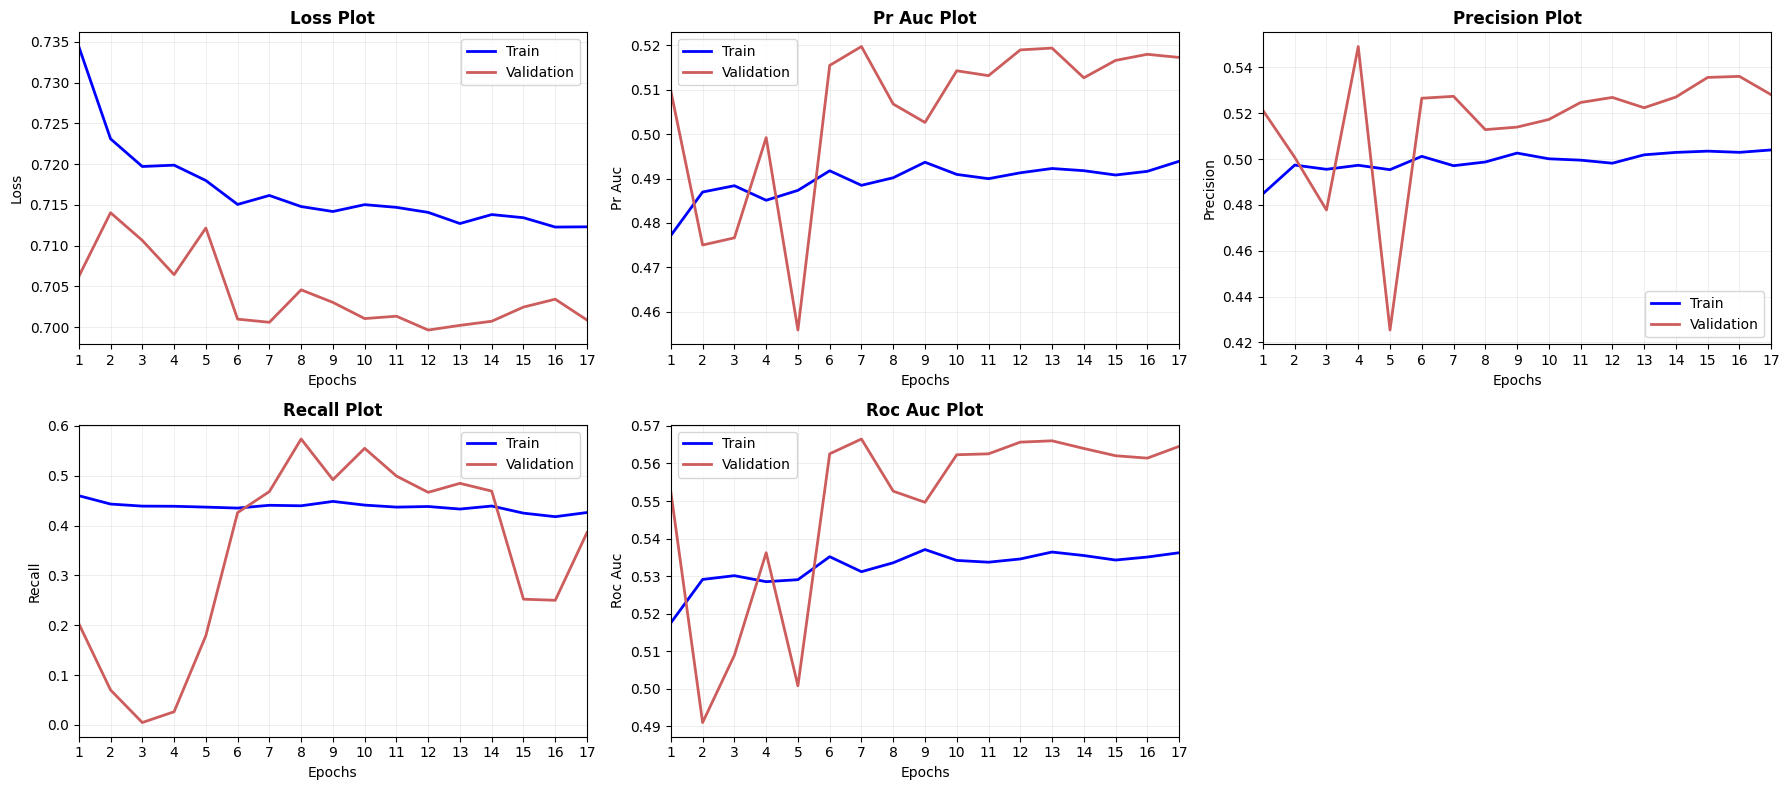

In [11]:
plot_model_report(history= init_history.history)

#### Part 3: Fine-tuning model of using Optuna

**3.1** Defining model architecture to be optimised:

In [20]:
def build_model_optuna(trial, input_dim= None):
    """
    Builds and compiles a Keras Sequential model based on hyperparameters suggested through an Optuna trial object.

    This function generates a neural network with a varying number of dense layers, kernel regularization, dropout rates,
    activation functions, and learning rate based on the trial configuration. The final layer is a single neuron with
    a sigmoid activation, tailored for binary classification.

    :param trial: Optuna trial object used to suggest hyperparameters for model configuration.
    :type trial: optuna.trial.Trial
    :param input_dim: Dimension of the input feature space. If None, a default value is used.
    :type input_dim: int, optional
    :return: A compiled Keras Sequential model configured with the trial's hyperparameters.
    :rtype: keras.models.Sequential
    """

    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)
    tf.keras.utils.set_random_seed(SEED)
    tf.keras.backend.clear_session()

    if input_dim is None:
        input_dim = features_shape

    n_dense_layers = trial.suggest_int('n_dense_layers', 2, 5)
    # float option:
    # kernel_regularizer = trial.suggest_float('kernel_regularizer', 1e-7, 1e-2, log= True)
    kernel_regularizer = trial.suggest_categorical("kernel_regularizer",[0.0, 1e-7, 1e-6, 1e-5])
    lr = trial.suggest_categorical('learning_rate', [0.0001, 0.001, 0.01, 0.1, 0.5, 0.95])
    drt = trial.suggest_float('dropout_rate', 0.0, 0.6, step= 0.1)
    # activation = 'relu'
    LeakyReLU_alpha = trial.suggest_categorical('LeakyReLU_alpha', [0.1, 0.2, 0.3, 0.4])

    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(input_dim,)))

    for layer_idx in range(n_dense_layers):
        units = trial.suggest_categorical(
            f'units_l{layer_idx + 1}',
            [64, 128, 256, 512, 1024]
        )

        model.add(
            keras.layers.Dense(
                units,
                use_bias= False,
                kernel_regularizer= keras.regularizers.l2(kernel_regularizer)
            )
        )
        model.add(keras.layers.BatchNormalization())
        #model.add(keras.layers.Activation(activation))
        model.add(keras.layers.LeakyReLU(alpha= LeakyReLU_alpha))
        model.add(keras.layers.Dropout(drt))

    model.add(keras.layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer= keras.optimizers.Adam(learning_rate= lr),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(curve = 'ROC', name= "roc_auc"),
            keras.metrics.AUC(curve="PR", name="pr_auc"),
            keras.metrics.Recall(name= "recall"),
            keras.metrics.Precision(name= "precision"),
                 ],
    )

    return model

**3.2** Defining fitting function (more hyper-parameters to be optimised):

In [21]:
def fit_model_optuna(trial, model, batch_size, positive_class_weight,  epochs= 20, verbose= 1):
    """
    Fits the given machine learning model using the Optuna trial configuration and provided parameters. This
    function trains the model, evaluates it on validation data, and returns the training history. The function
    supports early stopping based on validation recall to prevent overfitting.

    :param trial: An Optuna trial object used to tune hyperparameters.
    :param model: A machine learning model to be fitted.
    :param batch_size: The size of the batch during training.
    :param positive_class_weight: The weight given to the positive class in class weights.
    :param epochs: The maximum number of epochs to train the model (default is 20).
    :param verbose: Verbosity level of model training output (default is 1).
    :return: A training history object that contains details of the training process.
    """

    history = model.fit(
        X_train, y_train,
        validation_data= (X_val, y_val),
        epochs= epochs,
        batch_size= batch_size,
        class_weight= {0: 1.0, 1: positive_class_weight},
        callbacks=[
            keras.callbacks.EarlyStopping(
                        monitor= "val_pr_auc",
                        mode= "max",
                        patience= 10,
                        restore_best_weights= True
                    ),
            keras.callbacks.ReduceLROnPlateau(
                        monitor="val_pr_auc",
                        mode= "max",
                        factor= 0.5,
                        patience= 4,
                        min_lr= 1e-5
                    ),
        ],
        verbose= verbose,
    )

    return history

**3.3** Defining the objective function:

In [22]:
def objective_fn(trial, multiobjective= False):

    batch_size = trial.suggest_categorical('batch_size', [128, 256])
    positive_class_weight = trial.suggest_float('positive_class_weight', 1.0, 1.4, step= 0.05)

    model = build_model_optuna(trial)
    history = fit_model_optuna(trial,
                               model,
                               batch_size= batch_size,
                               positive_class_weight= positive_class_weight
                               )

    best_val_recall = max(history.history['val_recall'])
    best_epoch_recall = int(np.argmax(history.history['val_recall']) + 1)

    best_val_precision = max(history.history['val_precision'])
    best_epoch_precision = int(np.argmax(history.history['val_precision']) + 1)

    best_val_roc_auc = max(history.history['val_roc_auc'])
    best_epoch_roc_auc = int(np.argmax(history.history['val_roc_auc']) + 1)

    best_val_pr_auc = max(history.history['val_pr_auc'])
    best_epoch_pr_auc = int(np.argmax(history.history['val_pr_auc']) + 1)

    # best epoch's values
    trial.set_user_attr('best_epoch_roc_auc', best_epoch_roc_auc)

    trial.set_user_attr('best_epoch', best_epoch_pr_auc)

    trial.set_user_attr('best_epoch_recall', best_epoch_recall)
    trial.set_user_attr('best_epoch_precision', best_epoch_precision)

    # best metrics' values
    trial.set_user_attr('best_val_roc_auc', best_val_roc_auc)
    trial.set_user_attr('best_val_pr_auc', best_val_pr_auc)
    trial.set_user_attr('best_val_recall', best_val_recall)
    trial.set_user_attr('best_val_precision', best_val_precision)

    if multiobjective:
        return best_val_recall, best_val_pr_auc
    else:
        return best_val_recall


**3.4** Running the optimization (study):

In [45]:
def extract_best_params(study, multiobjective= False, choose_trial= 0):

    if multiobjective:
        best_params = study.best_trials[choose_trial].params
    else:
        best_params = study.best_params

    return best_params

In [25]:
# to load the existing study
# (saved under the model folder as a SQLite db format)
load_existing_study = True

# set a multiobjective optimization
multiobjective = True


###### ###### ######
storage_path =  f"sqlite:///{export_dir / 'optuna_study_2.db'}"
num_trials = 30
sec_timeout = 3600

In [26]:
if multiobjective:
    study = optuna.create_study(
        study_name= "dnn_v1_optuna",
        directions = ['maximize', 'maximize'],
        storage= storage_path,
        load_if_exists= True,
    )
else:
    study = optuna.create_study(
        study_name="dnn_v1_optuna",
        direction= 'maximize',
        storage= storage_path,
        load_if_exists= True,
    )


# load existing study if exists
# (do not run it again)
if load_existing_study == False:
        study.optimize(
            func = partial(objective_fn,
                           multiobjective= multiobjective),
            n_trials= num_trials,
            timeout= sec_timeout
        )

[I 2026-07-15 15:04:24,395] Using an existing study with name 'dnn_v1_optuna' instead of creating a new one.


In [53]:
# extracting best parameters from the study
best_params = extract_best_params(study,
                                  multiobjective= True,
                                  choose_trial= 1)

best_params

{'batch_size': 128,
 'positive_class_weight': 1.05,
 'n_dense_layers': 4,
 'kernel_regularizer': 1e-05,
 'learning_rate': 0.0001,
 'dropout_rate': 0.1,
 'LeakyReLU_alpha': 0.1,
 'units_l1': 256,
 'units_l2': 256,
 'units_l3': 64,
 'units_l4': 64}

**3.5** Creating the final fine-tuned model:

In [55]:
def build_model_fine_tuned(
                       input_dim= None,
                       best_parameters = best_params,
                       fit_model = True,
                       epochs= 20,
                       verbose= 1):

    # setting the seed for reproducibility
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)
    tf.keras.utils.set_random_seed(SEED)
    tf.keras.backend.clear_session()

    # getting the input dimensions
    # (shape of features)
    if input_dim is None:
        input_dim = features_shape

    ### extracting the best parameters from the study
    # model architecture
    n_dense_layers = best_parameters['n_dense_layers']
    kernel_regularizer = best_parameters['kernel_regularizer']
    lr = best_parameters['learning_rate']
    drt = best_parameters['dropout_rate']
    # batch size and positive class weight
    batch_size = best_parameters['batch_size']
    positive_class_weight = best_parameters['positive_class_weight']
    LeakyReLU_alpha = best_parameters['LeakyReLU_alpha']


    # initialising the Sequential model
    # and the input layer
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(input_dim,)))

    for layer_idx in range(n_dense_layers):
        # extracting units
        units = best_parameters[f'units_l{layer_idx + 1}']

        # adding dense layer with the best units
        model.add(keras.layers.Dense(
            units, use_bias= False,
            kernel_initializer='he_normal',
            kernel_regularizer= keras.regularizers.l2(kernel_regularizer)
        ))
        # always use batch normalization,
        # activation and dropout layers
        # after the dense layer
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.LeakyReLU(alpha= LeakyReLU_alpha))
        model.add(keras.layers.Dropout(drt))

    # output layer (sigmoid function)
    model.add(keras.layers.Dense(1, activation='sigmoid'))
    # compiling model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate= lr),
        loss='binary_crossentropy',
        metrics= [
            keras.metrics.AUC(name='auc'),
            keras.metrics.Recall(name='recall')
        ],
    )

    # fitting the model and creating a history
    # if fit_model is True
    history = None
    if fit_model:
        # fitting the model using the best parameters
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs= epochs,
            batch_size=batch_size,
            class_weight= {0: 1.0, 1: positive_class_weight},
            callbacks=[
                keras.callbacks.EarlyStopping(
                    monitor= 'val_recall',
                    mode= 'max',
                    patience= 10,
                    restore_best_weights=True
                )
            ],
            verbose= verbose,
        )

    return model, history

**Getting the structure of the model without fitting it first**:

In [ ]:
model_finetuned, _ = build_model_fine_tuned(input_dim= None,
                           best_parameters = best_params,
                           fit_model = False,
                           epochs= 20,
                           verbose= 1)
model_finetuned.summary()

**Fitting the fine-tuned model**:

In [58]:
model_finetuned, history_fine_tuned = build_model_fine_tuned(input_dim= None,
                                                             best_parameters = best_params,
                                                             fit_model = True,
                                                             epochs= 20,
                                                             verbose= 1)

/Users/vassilistsoubris/PycharmProjects/ds207_final_project/.venv/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/20
466/466 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - auc: 0.5175 - loss: 0.7620 - recall: 0.7266 - val_auc: 0.5331 - val_loss: 0.7043 - val_recall: 0.6935
Epoch 2/20
466/466 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - auc: 0.5266 - loss: 0.7320 - recall: 0.5064 - val_auc: 0.5359 - val_loss: 0.7007 - val_recall: 0.4970
Epoch 3/20
466/466 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - auc: 0.5345 - loss: 0.7255 - recall: 0.4827 - val_auc: 0.5648 - val_loss: 0.6982 - val_recall: 0.6102
Epoch 4/20
466/466 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc: 0.5363 - loss: 0.7231 - recall: 0.4776 - val_auc: 0.5263 - val_loss: 0.6985 - val_recall: 0.3339
Epoch 5/20
466/466 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc: 0.5382 - loss: 0.7209 - recall: 0.4703 - val_auc: 0.5625 - val_loss: 0.6948 - val_recall: 0.5978
Epoch 6/20
466/466 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc: 0.5407 - loss: 0.7203 - recall: 0.4734 - val_auc: 0.5631 - val_loss: 0.6930 - val_recall: 0.4488
Epoch 7/20
466/466 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc: 0.538

**Plotting AUC, Recall and Loss of the fine-tuned model (train & validation set)**:

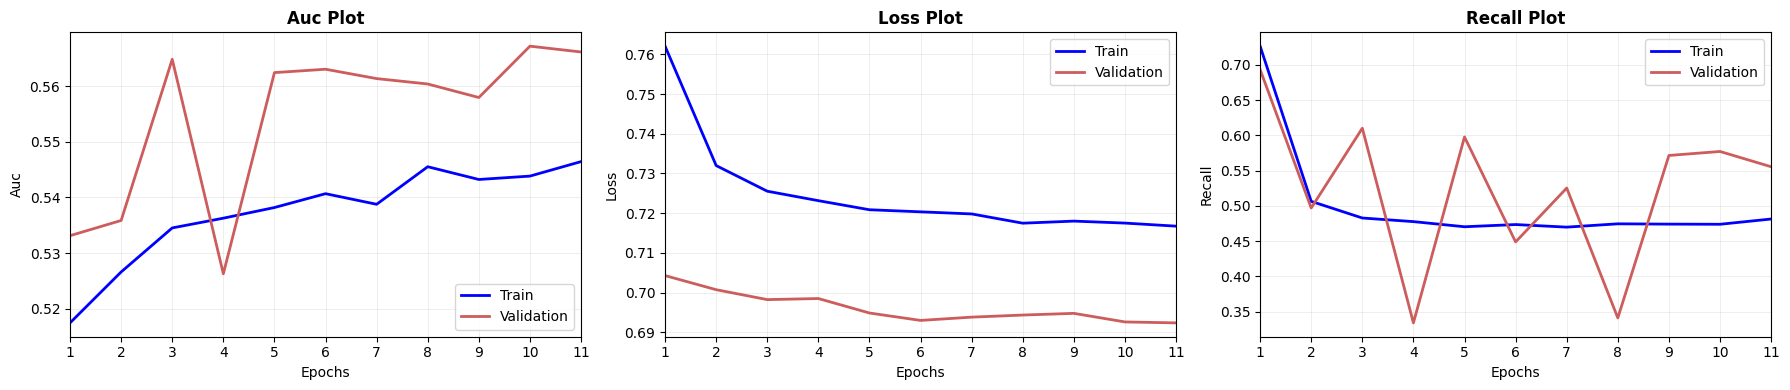

In [59]:
plot_model_report(history= history_fine_tuned.history)

### Part 4: Converting predictions to binary

1863/1863 ━━━━━━━━━━━━━━━━━━━━ 2s 967us/step
621/621 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

           0       0.57      0.37      0.45     31515
           1       0.49      0.69      0.58     28090

    accuracy                           0.52     59605
   macro avg       0.53      0.53      0.51     59605
weighted avg       0.54      0.52      0.51     59605

              precision    recall  f1-score   support

           0       0.58      0.37      0.45     10506
           1       0.50      0.69      0.58      9363

    accuracy                           0.52     19869
   macro avg       0.54      0.53      0.52     19869
weighted avg       0.54      0.52      0.51     19869



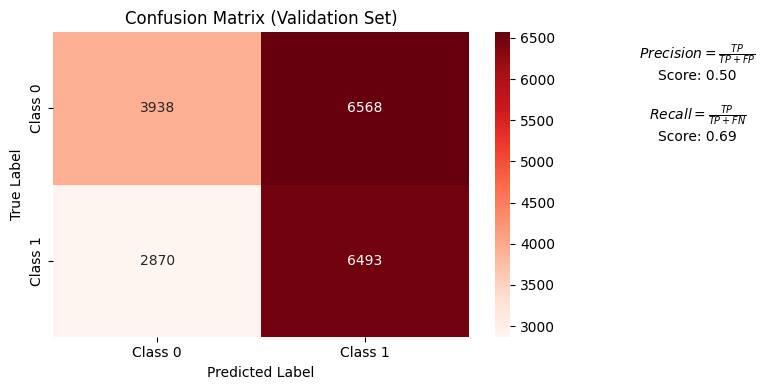

In [74]:
# after training the model
ypred_train_proba = model_finetuned.predict(X_train)
ypred_val_proba = model_finetuned.predict(X_val)

# converting to binary predictions
ypred_train_binary = (ypred_train_proba >= 0.5).astype(int).flatten()
ypred_val_binary = (ypred_val_proba >= 0.5).astype(int).flatten()

# Now evaluate using your evaluation function
recall_tr, precision_tr, f1_tr, acc_tr, cl_report_tr = \
    evaluate_predictions(true_values= y_train,
                        predictions= ypred_train_binary,
                        print_class_report= True)

recall_vl, precision_vl, f1_vl, acc_vl, cl_report_vl = \
    evaluate_predictions(true_values= y_val,
                        predictions= ypred_val_binary,
                        print_class_report= True)

# Plot confusion matrix (validation set)
scores = plot_confusion_matrix(y_true= y_val['readmitted'],
                     y_pred= ypred_val_binary,
                     fig_size= (8,4),
                     title='Confusion Matrix (Validation Set)',
                     colour_map='Reds')

### Part 5: Test Set Evaluation

Generating predictions on test data...
621/621 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test set size: 19869 samples
Predictions generated: 19869


              precision    recall  f1-score   support

           0       0.57      0.38      0.45     10506
           1       0.49      0.68      0.57      9363

    accuracy                           0.52     19869
   macro avg       0.53      0.53      0.51     19869
weighted avg       0.53      0.52      0.51     19869



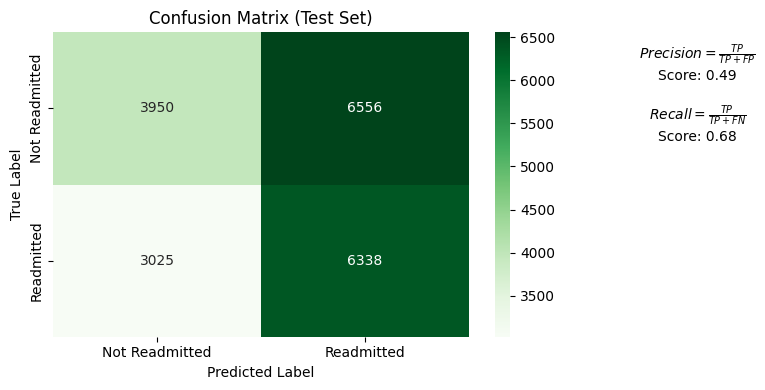

In [72]:
# Generate predictions on test set
print("Generating predictions on test data...")
ypred_test_proba = model_finetuned.predict(X_test)
# Convert to binary predictions (threshold = 0.5)
ypred_test_binary = (ypred_test_proba >= 0.5).astype(int).flatten()

print(f"Test set size: {len(y_test)} samples")
print(f"Predictions generated: {len(ypred_test_binary)}")
print("\n")

# Classification Report:
recall_test, precision_test, f1_test, acc_test, cl_report_test = \
    evaluate_predictions(true_values= y_test,
                         predictions= ypred_test_binary,
                         print_class_report= True)


# confusion matrix
scores_test = plot_confusion_matrix(y_true=y_test['readmitted'],
                                    y_pred=ypred_test_binary,
                                    fig_size=(8, 4),
                                    class_names=['Not Readmitted', 'Readmitted'],
                                    title='Confusion Matrix (Test Set)',
                                    colour_map='Greens'
                                    )


In [73]:
# Summarising evaluation metrics
print("\n")
print("-" * 30)
print("TEST SET PERFORMANCE SUMMARY")
print("-" * 30)
print(f"Accuracy:  {acc_test:.4f}")
print(f"Recall:    {recall_test:.4f}")
print(f"Precision: {precision_test:.4f}")
print(f"F1-Score:  {f1_test:.4f}")
print("-" * 30)
print("\n")

# storing results for comparison
test_results = {
    'dataset': 'test',
    'n_samples': len(y_test),
    'accuracy': acc_test,
    'recall': recall_test,
    'precision': precision_test,
    'f1_score': f1_test,
    'confusion_matrix': scores_test['confusion_matrix']
}



------------------------------
TEST SET PERFORMANCE SUMMARY
------------------------------
Accuracy:  0.5178
Recall:    0.6769
Precision: 0.4915
F1-Score:  0.5695
------------------------------




In [64]:
test_results

{'dataset': 'test',
 'n_samples': 19869,
 'accuracy': 0.5177915345513111,
 'recall': 0.676919790665385,
 'precision': 0.4915464557158368,
 'f1_score': 0.5695286876038999,
 'confusion_matrix': array([[3950, 6556],
        [3025, 6338]])}